Dummy dataset of different clusters with a neural network that attempts to predict the membership of points to each cluster. The network is optimized using the `genalg` module.

In [1]:
import numpy as np
import numpy.typing as npt
from matplotlib import pyplot as plt
import pandas as pd
from algorithms.neural.nn import Layer, NeuralNetwork
from algorithms.neural.plotting import NetworkPlotter
from algorithms.genalg import GeneticAlgorithm, selection, crossover, mutation

# Data functions

In [2]:
def create_clusters(num_clusters: int, num_points_per_cluster) -> npt.NDArray[np.float64]:
    """
    Generate a number of points that have membership to a given number of clusters.
    """
    clusters = np.zeros((num_clusters, num_points_per_cluster, 2))

    for cluster_idx in range(num_clusters):
        midpoint = np.random.uniform(-1, 1, 2)
        spread = np.random.uniform(0.025, 0.4)
        clusters[cluster_idx] = np.random.normal(midpoint, spread, (num_points_per_cluster,2))
    return clusters


def plot_clusters(clusters: npt.NDArray[np.float64]):
    """
    Visualize the points for each cluster.
    """
    fig, ax = plt.subplots(figsize=(5,5))
    for cluster_idx, cluster_points in enumerate(clusters):
        ax.scatter(*cluster_points.T, alpha=0.6, s=5)
    ax.set_xlim((-1.5, 1.5))
    ax.set_ylim((-1.5, 1.5))
    plt.show()


def create_dataframe(clusters: npt.NDArray[np.float64]) -> pd.DataFrame:
    """
    Create a DataFrame of (x,y) points and their cluster membership.
    """
    points = clusters.reshape((-1, 2))
    membership = np.repeat(np.arange(clusters.shape[0]), clusters.shape[1])
    df = pd.DataFrame(data={"x":points[:,0], "y":points[:,1], "cluster":membership})
    return df

# GA and NN functions

In [3]:
def initialize_nn(num_clusters, num_hidden_layers, hidden_layer_dim):
    network = NeuralNetwork(input_dim=2)
    network.add_layer(Layer(size=hidden_layer_dim, input_dim=2))
    for _ in range(num_hidden_layers - 1):
        network.add_layer(
            Layer(size=hidden_layer_dim, input_dim=hidden_layer_dim))
    network.add_layer(Layer(size=num_clusters, input_dim=hidden_layer_dim))
    return network


def initialize_ga(
        tournament_k: int, mutation_probability: float) -> GeneticAlgorithm:
    ga = GeneticAlgorithm(
        selection=selection.Tournament(k=tournament_k),
        crossover=crossover.Multipoint(n=4),
        mutations=[mutation.UniformReplacement(p=mutation_probability)],
        num_elites=1)
    return ga


def initialize_population(
        pop_size: int, genome_size: int) -> npt.NDArray[np.int_]:
    """
    Create a population of a given number of random NN parameters.
    """
    population = np.random.uniform(-1, 1, (pop_size, genome_size))
    return population   

# Training functions

In [53]:
def predict_points(
        points: npt.NDArray[np.float64], 
        network: NeuralNetwork) -> npt.NDArray[np.int_]:
    """
    Use the neural network to predict a list of points.
    """
    predicted_clusters = np.zeros(points.shape[0], dtype=np.int_)
    for i, xy in enumerate(points):
        output_values, selection = network.forward_pass(xy)
        predicted_clusters[i] = selection
    return predicted_clusters


def evaluate_population_fitness(
        df_points: pd.DataFrame, population: npt.NDArray[np.float64], 
        network: NeuralNetwork) -> npt.NDArray[np.float64]:
    """
    Use the genomes of a population to predict each point and return the accuracy.
    """
    population_fitness = np.zeros(population.shape[0])

    for i, genome in enumerate(population):
        network.set_genome(genome)
        predicted_clusters = predict_points(
            df_points[["x", "y"]].values, network)
        accuracy = (predicted_clusters == df_points["cluster"].values).mean()
        population_fitness[i] = accuracy
    
    return population_fitness


def train_network(
        network: NeuralNetwork, ga: GeneticAlgorithm, 
        train_points: npt.NDArray[np.float64], population: npt.NDArray[np.int_], 
        num_iterations: int) -> tuple[npt.NDArray]:
    log_fitness = np.zeros((num_iterations, len(population)))
    log_genomes = np.zeros((num_iterations, len(population), network.genome_size))

    for i in range(num_iterations):
        fitness = evaluate_population_fitness(train_points, population, network)
        log_fitness[i] = fitness
        log_genomes[i] = population
        population = ga.evolve_population(population, fitness)
        
        if i % int(num_iterations / 20) == 0:
            print(f"{round(100*i/num_iterations,0)}%   best = {fitness.max()}")

    print("done")
    
    return log_fitness, log_genomes

# Testing and analysis functions

In [121]:
def plot_test_results(
        df_test: pd.DataFrame, actual_clusters:npt.NDArray[np.int_],
        predicted_clusters: npt.NDArray[np.int_]):
    """
    Plot the points in the test dataset with with highlighted errors.
    """
    is_correct = actual_clusters == predicted_clusters
    fig, ax = plt.subplots(figsize=(5,5))

    # Print correct predictions
    for cluster in df_test["cluster"].unique():
        points = df_test[
            is_correct & (df_test["cluster"]==cluster)][["x", "y"]].values
        ax.scatter(*points.T, s=5, alpha=0.5, label=cluster)

    # Print correct predictions
    for cluster in df_test["cluster"].unique():
        points = df_test[
            ~is_correct & (df_test["cluster"]==cluster)][["x", "y"]].values
        ax.scatter(*points.T, s=30, alpha=0.8, color="red")

    ax.legend()

    plt.show()


def plot_behavior_grid(network: NeuralNetwork, grid_resolution: int):
    """
    Visualize the probablity of points being assigned to each cluster in the nn.
    """
    num_clusters = network.layers[-1].size
    n = grid_resolution
    grid = np.transpose(-1.5 + (3*np.indices((n,n))/n))
    predictions = np.zeros((n, n, num_clusters))

    for i in range(n):
        for j in range(n):
            output_values, selection = network.forward_pass(grid[i,j])
            predictions[i,j] = output_values

    fig, axs = plt.subplots(ncols=num_clusters, figsize=(2*num_clusters, 3))
    for i in range(num_clusters):
        axs[i].imshow(predictions[:,:,i], origin="lower", cmap="Greys")
        axs[i].set_title(f"cluster {i}")
        axs[i].set_xticks([])
        axs[i].set_yticks([])
    
    fig.tight_layout()
    plt.show()
    return predictions


def plot_grid_predictions(predictions):
    """
    Plot predicted cluster for each point in the grid
    """
    fig, ax = plt.subplots(figsize=(5,5))

    n = predictions.shape[0]
    grid_highest_cluster = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            grid_highest_cluster[i,j] = predictions[i,j].argmax()

    ax.imshow(grid_highest_cluster, origin="lower", cmap="Greys")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("Cluster selection for evenly spaced out cells")
    plt.show()

# NN optimization

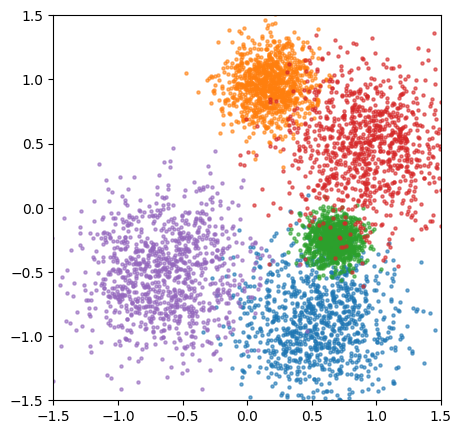

,x,y,cluster
0,0.466556,-0.543990,0
1,0.667145,-0.716879,0
2,0.001260,-0.822472,0
3,0.366254,-0.966701,0
4,0.453578,-0.424592,0
...,...,...,...
4995,-0.681681,-0.314939,4
4996,-0.619376,-0.781564,4
4997,-0.110993,-0.946627,4
4998,-0.561133,-0.546913,4


In [13]:
# Create a dummy dataset of cluster
clusters = create_clusters(num_clusters=5, num_points_per_cluster=1000)
df_clusters = create_dataframe(clusters)

plot_clusters(clusters)

df_clusters

In [55]:
# Initialize alorithms and population
network = initialize_nn(
    num_clusters=clusters.shape[0],
    num_hidden_layers=2,
    hidden_layer_dim=6)

initial_population = initialize_population(
    pop_size=100,
    genome_size=network.genome_size)

ga = initialize_ga(
    tournament_k=5,
    mutation_probability=0.03)

# Train test split on points
df_train = df_clusters.sample(frac=0.8)
df_test = df_clusters.drop(df_train.index)

# Train network
log_fitness, log_genomes = train_network(
    network, ga, df_train, initial_population, num_iterations=50)

0.0%   best = 0.4015
4.0%   best = 0.54325
8.0%   best = 0.58575
12.0%   best = 0.602
16.0%   best = 0.602
20.0%   best = 0.602
24.0%   best = 0.68
28.0%   best = 0.68
32.0%   best = 0.727
36.0%   best = 0.727
40.0%   best = 0.727
44.0%   best = 0.7945
48.0%   best = 0.8145
52.0%   best = 0.8145
56.0%   best = 0.84275
60.0%   best = 0.84275
64.0%   best = 0.84275
68.0%   best = 0.84275
72.0%   best = 0.84275
76.0%   best = 0.86125
80.0%   best = 0.8875
84.0%   best = 0.8875
88.0%   best = 0.908
92.0%   best = 0.908
96.0%   best = 0.908
done


# Analysis

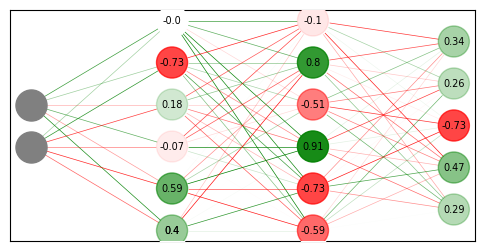

In [56]:
# Extract and plot the best network
best_idx = np.unravel_index(log_fitness.argmax(), log_fitness.shape)
network.set_genome(log_genomes[best_idx])

fig, ax = plt.subplots(figsize=(6,3))
plotter = NetworkPlotter(network, scale=1)
plotter.pyplot_structure(ax, node_size=500, font_size=7, font_offset=(0,0))
plt.show()

In [57]:
# Evaluate the final network based on the test dataset
actual_clusters = df_test["cluster"]
predicted_clusters = predict_points(
    df_test[["x", "y"]].values, network)
accuracy = (actual_clusters == predicted_clusters).mean()

accuracy

np.float64(0.907)

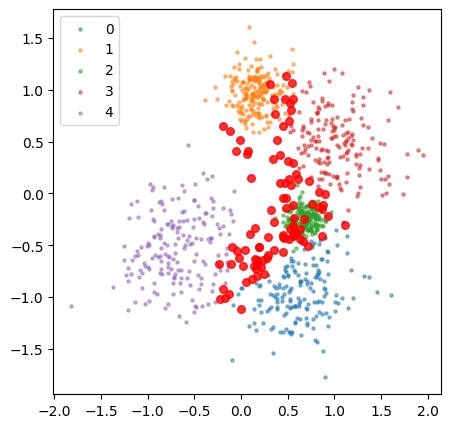

In [58]:
# Visualize errors
plot_test_results(df_test, actual_clusters, predicted_clusters)

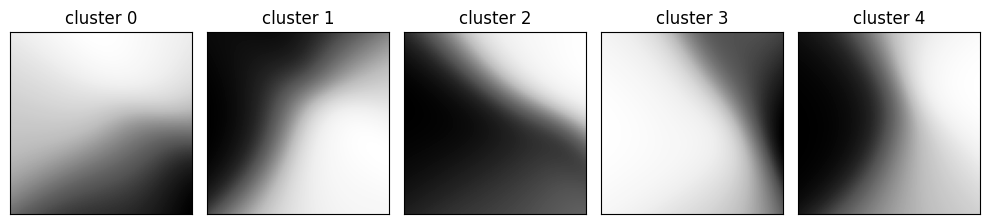

In [127]:
# Visualize prediction behavior for all locations in the grid
predictions = plot_behavior_grid(network, grid_resolution=100)

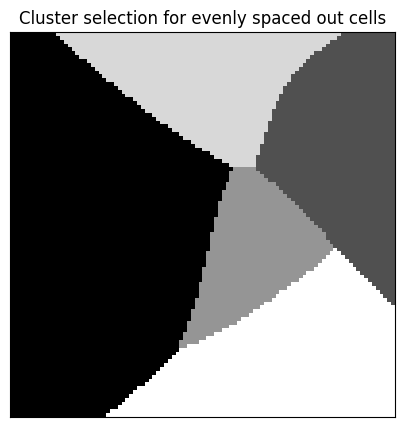

In [128]:
plot_grid_predictions(predictions)